# ANN on Multiclass classification

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical #similar to OHE converts categorical to numerical in the format of 0's and 1's
from tensorflow.keras.callbacks import EarlyStopping # stops the training when validation loss stops improving to prevent overfitting
from sklearn.metrics import classification_report, accuracy_score

In [2]:
df = pd.read_csv("bodyPerformance.csv")
df

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B
...,...,...,...,...,...,...,...,...,...,...,...,...
13388,25.0,M,172.1,71.80,16.2,74.0,141.0,35.8,17.4,47.0,198.0,C
13389,21.0,M,179.7,63.90,12.1,74.0,128.0,33.0,1.1,48.0,167.0,D
13390,39.0,M,177.2,80.50,20.1,78.0,132.0,63.5,16.4,45.0,229.0,A
13391,64.0,F,146.1,57.70,40.4,68.0,121.0,19.3,9.2,0.0,75.0,D


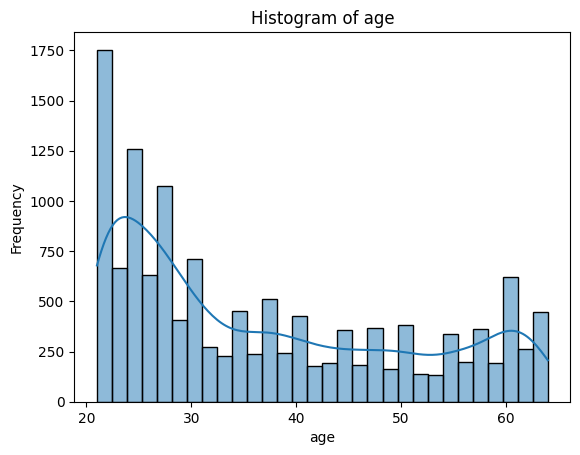

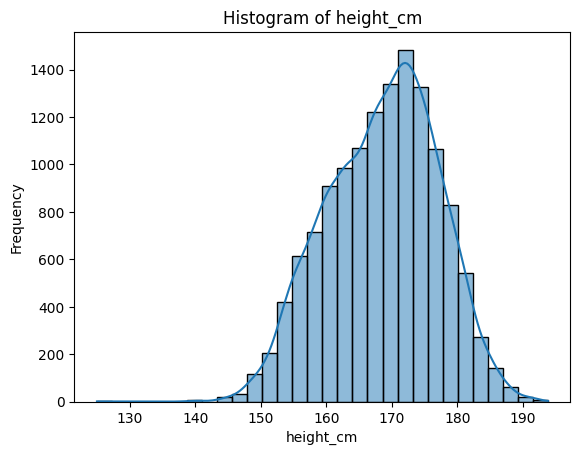

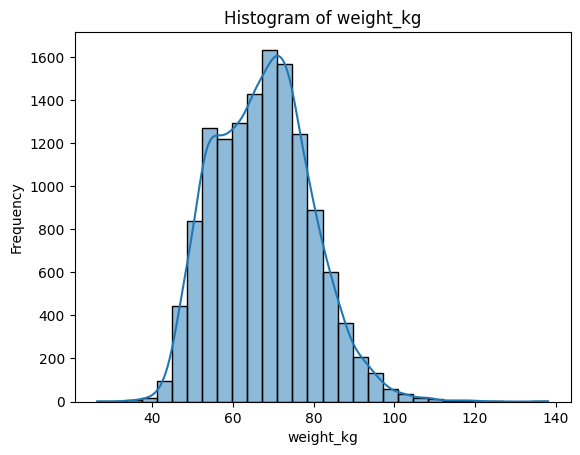

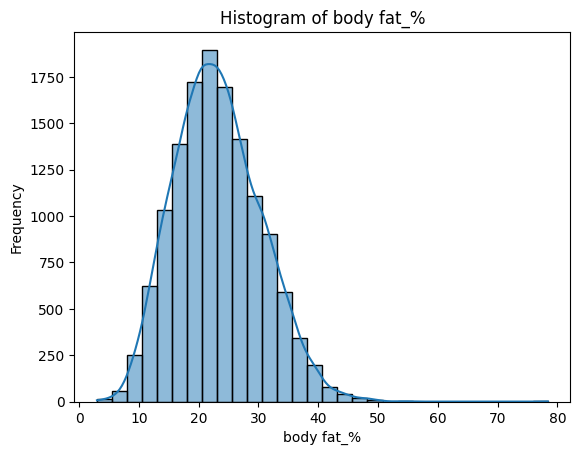

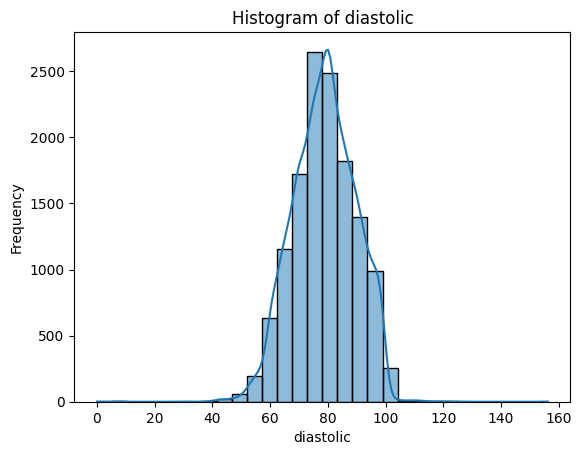

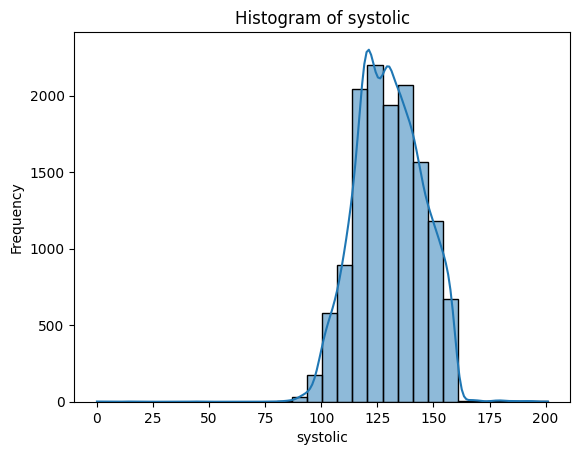

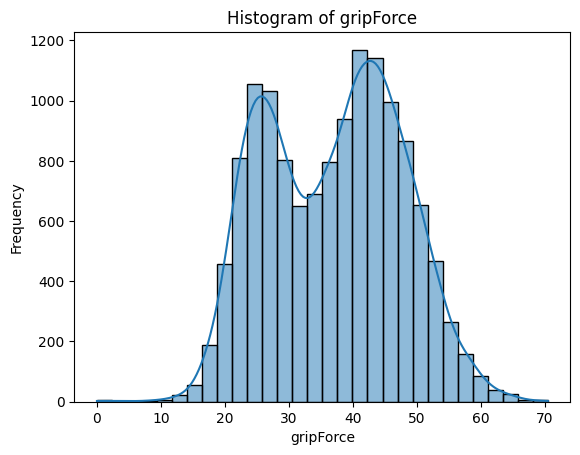

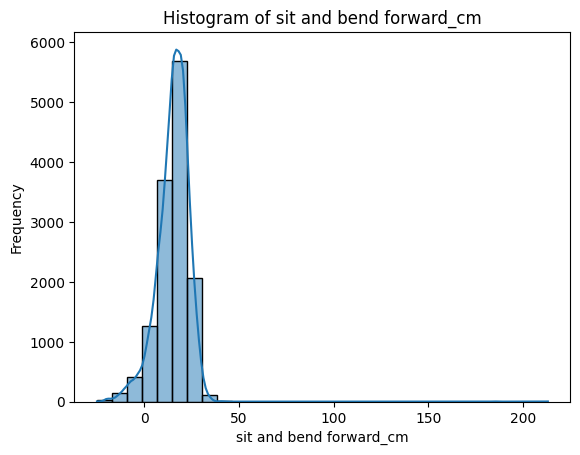

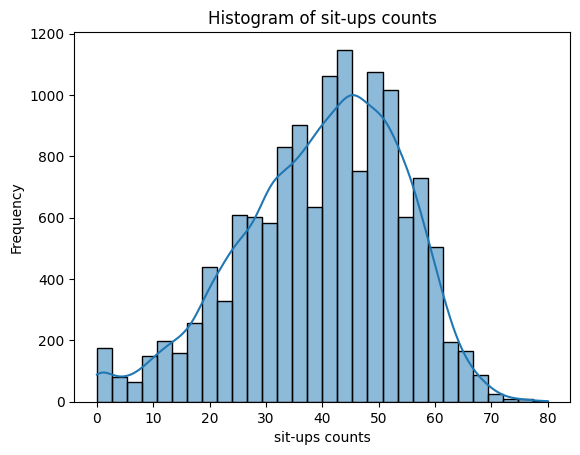

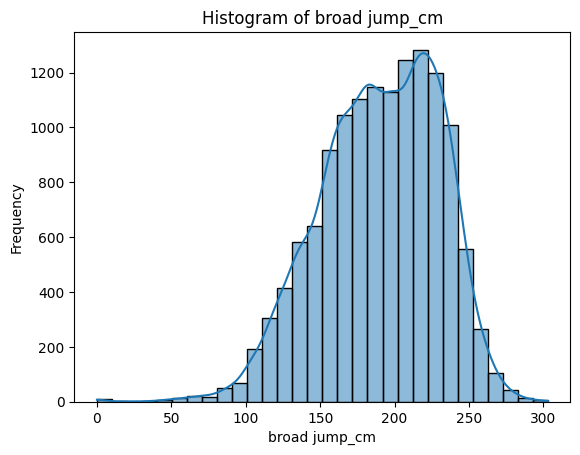

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

columns=['age','height_cm','weight_kg', 'body fat_%', 'diastolic',
       'systolic', 'gripForce', 'sit and bend forward_cm', 'sit-ups counts',
       'broad jump_cm',]

# loops through the columns
for a in columns:
  plt.figure()

  sns.histplot(df[a],bins=30, kde=True)

  plt.title(f"Histogram of {a}")
  plt.xlabel(a)
  plt.ylabel('Frequency')

  plt.show()

In [3]:
df.columns

Index(['age', 'gender', 'height_cm', 'weight_kg', 'body fat_%', 'diastolic',
       'systolic', 'gripForce', 'sit and bend forward_cm', 'sit-ups counts',
       'broad jump_cm', 'class'],
      dtype='object')

In [6]:
# Convert class labels (A, B, C, D) to numeric form (0, 1, 2, 3)
le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])
df['gender'] = le.fit_transform(df['gender'])

In [7]:
df

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,1,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,2
1,25.0,1,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,0
2,31.0,1,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,2
3,32.0,1,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,1
4,28.0,1,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
13388,25.0,1,172.1,71.80,16.2,74.0,141.0,35.8,17.4,47.0,198.0,2
13389,21.0,1,179.7,63.90,12.1,74.0,128.0,33.0,1.1,48.0,167.0,3
13390,39.0,1,177.2,80.50,20.1,78.0,132.0,63.5,16.4,45.0,229.0,0
13391,64.0,0,146.1,57.70,40.4,68.0,121.0,19.3,9.2,0.0,75.0,3


In [8]:
X = df.drop('class', axis=1)
y = df['class']

In [9]:
print(df['class'].value_counts())

class
2    3349
3    3349
0    3348
1    3347
Name: count, dtype: int64


In [10]:
# Split first — to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
X_train

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm
6288,28.0,1,179.5,75.0,15.3,85.0,135.0,45.0,10.0,50.0,210.0
335,29.0,1,172.7,71.8,15.7,86.0,148.0,52.2,19.7,57.0,254.0
12056,39.0,1,177.7,68.6,19.1,87.0,147.0,40.4,2.8,44.0,240.0
8093,43.0,0,156.4,50.0,19.3,73.0,123.0,32.4,23.8,34.0,175.0
1278,23.0,1,170.8,60.3,11.5,88.0,129.0,38.9,20.1,45.0,232.0
...,...,...,...,...,...,...,...,...,...,...,...
13232,23.0,0,155.5,55.0,26.2,66.0,103.0,30.9,29.4,53.0,200.0
7242,21.0,1,178.0,71.7,20.4,78.0,117.0,39.9,5.3,54.0,179.0
7654,25.0,1,172.6,63.9,16.4,82.0,135.0,44.1,17.7,51.0,255.0
3498,39.0,0,160.6,52.2,33.9,51.0,91.0,22.6,21.8,29.0,141.0


In [12]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

In [15]:
y_test_cat

array([[0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 1., 0.],
       ...,
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [0., 0., 0., 1.]])

In [16]:
model = Sequential([
    Dense(2 * X_train_scaled.shape[1], activation='relu', input_shape=(X_train_scaled.shape[1],)),  # Hidden Layer
    Dense(4, activation='softmax')  # Output Layer (4 classes → softmax activation)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [18]:
early_stop = EarlyStopping(monitor='val_loss', patience=10)

In [19]:
# Train the Model
history = model.fit(
    X_train_scaled, y_train_cat,
    epochs=200,
    validation_split=0.2,
    verbose=1,
    callbacks=[early_stop] #Stops training when validation loss stops improving (prevents overfitting).
)

Epoch 1/200
268/268 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3679 - loss: 1.3387 - val_accuracy: 0.4083 - val_loss: 1.2951
Epoch 2/200
268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4631 - loss: 1.2455 - val_accuracy: 0.4704 - val_loss: 1.2047
Epoch 3/200
268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4977 - loss: 1.1606 - val_accuracy: 0.5012 - val_loss: 1.1273
Epoch 4/200
268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5246 - loss: 1.0917 - val_accuracy: 0.5250 - val_loss: 1.0660
Epoch 5/200
268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5394 - loss: 1.0433 - val_accuracy: 0.5352 - val_loss: 1.0255
Epoch 6/200
268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5484 - loss: 1.0141 - val_accuracy: 0.5483 - val_loss: 1.0022
Epoch 7/200
268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5531 - loss: 0.9943 - val_accuracy: 0.5418 - val_loss: 0.9880
Epoch 8/200
268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5600 - loss: 0.9810 - val_accu

In [20]:
y_pred = model.predict(X_test_scaled)
y_pred_classes = np.argmax(y_pred, axis=1)

84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [21]:
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test, y_pred_classes)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[537 131   2   0]
 [174 315 167  13]
 [ 67 116 427  60]
 [ 14  26 130 500]]


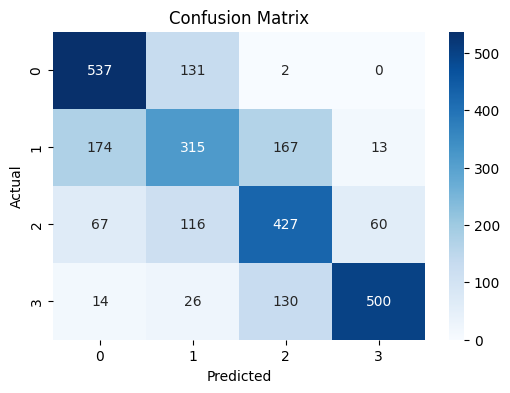

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [23]:
print("Test Accuracy:", accuracy_score(y_test, y_pred_classes))
print("\nClassification Report:\n", classification_report(y_test, y_pred_classes))

Test Accuracy: 0.6640537513997761

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.80      0.73       670
           1       0.54      0.47      0.50       669
           2       0.59      0.64      0.61       670
           3       0.87      0.75      0.80       670

    accuracy                           0.66      2679
   macro avg       0.67      0.66      0.66      2679
weighted avg       0.67      0.66      0.66      2679

